# Histo Region Embedding Analysis

Tissue tiles from a single WSI are partitioned into 5 regions based on BFS distance to the tumor. Tiles are sampled from each region, and their ImageNet (`_i`) and SSL (`_s`) embeddings are projected with UMAP to see whether the two feature spaces carry any spatial structure.

| Region | Distance to Tumor |
|--------|------------------|
| Tumor  | 0                |
| a (1-5)  | 1 – 5          |
| b (6-10) | 6 – 10         |
| c (11-20)| 11 – 20        |
| d (21+)  | 21 – ∞         |

## 1. Imports & Configuration

In [ ]:
import importlib
import numpy as np
import h5py
import matplotlib.pyplot as plt
import umap

import wsi_env as wsi_env_module
importlib.reload(wsi_env_module)
from wsi_env import WSIEnv

# Parameters
H5_PATH = "tile_database/tumor_011.h5"
SAMPLES_PER_REGION = 200          # tiles to sample from each region
RANDOM_SEED = 42

# Regions: name → (dist_min, dist_max)
# Tumor region is handled separately (distance == 0)
NON_TUMOR_REGIONS = {
    'a (1-5)':   (1, 5),
    'b (6-10)':  (6, 10),
    'c (11-20)': (11, 20),
    'd (21+)':   (21, 9999),
}

print(f"H5 file : {H5_PATH}")
print(f"Samples per region: {SAMPLES_PER_REGION}")

H5 file : tile_database/tumor_011.h5
Samples per region: 200


## 2. Load Environment & Compute Distance Map

In [2]:
# Create env with distance_band mode to trigger BFS distance computation
env = WSIEnv(H5_PATH, max_steps=100, embedding_suffix='_i',
             start_mode='distance_band', start_dist_range=(1, 5))

dist_map = env._dist_to_tumor

print(f"Grid shape : {env.n_rows} x {env.n_cols}")
print(f"Tissue tiles: {env.tissue_grid.sum()}")
print(f"Tumor tiles : {env.tumor_grid.sum()}")
print(f"Max BFS dist: {dist_map[dist_map >= 0].max()}")
print()

# Show pool sizes for each region
tumor_pool = np.argwhere(env.tumor_grid)
print(f"Tumor region: {len(tumor_pool)} tiles")
for name, (d_min, d_max) in NON_TUMOR_REGIONS.items():
    pool = env.get_start_pool(d_min, d_max)
    print(f"Region {name}: {len(pool)} tiles")

Grid shape : 493 x 218
Tissue tiles: 24347
Tumor tiles : 1108
Max BFS dist: 125

Tumor region: 1108 tiles
Region a (1-5): 1588 tiles
Region b (6-10): 1443 tiles
Region c (11-20): 3051 tiles
Region d (21+): 13526 tiles


## 3. Sample Tiles from Each Region

In [3]:
rng = np.random.default_rng(RANDOM_SEED)

def sample_from_pool(pool, n, rng):
    """Sample n tiles from pool (with replacement if pool < n)."""
    if len(pool) == 0:
        raise ValueError("Empty pool, cannot sample")
    replace = len(pool) < n
    indices = rng.choice(len(pool), size=n, replace=replace)
    return pool[indices]

# Build sampled (row, col) + region labels
all_regions = {'Tumor': tumor_pool}
for name, (d_min, d_max) in NON_TUMOR_REGIONS.items():
    all_regions[name] = env.get_start_pool(d_min, d_max)

sampled_rc = []     # (row, col) pairs
region_labels = []  # region name for each sample

for region_name, pool in all_regions.items():
    n = min(SAMPLES_PER_REGION, len(pool))
    chosen = sample_from_pool(pool, n, rng)
    sampled_rc.append(chosen)
    region_labels.extend([region_name] * n)
    print(f"{region_name:15s}: sampled {n} / {len(pool)} tiles")

sampled_rc = np.vstack(sampled_rc)  # (total, 2)
region_labels = np.array(region_labels)
print(f"\nTotal sampled tiles: {len(region_labels)}")

Tumor          : sampled 200 / 1108 tiles
a (1-5)        : sampled 200 / 1588 tiles
b (6-10)       : sampled 200 / 1443 tiles
c (11-20)      : sampled 200 / 3051 tiles
d (21+)        : sampled 200 / 13526 tiles

Total sampled tiles: 1000


## 4. Extract Embeddings (_i and _s)

In [5]:
# Convert (row, col) → flat index for HDF5 lookup
flat_indices = np.array([env._rc_to_idx(r, c) for r, c in sampled_rc])

# h5py fancy indexing requires indices in strictly increasing order.
# Sort them, fetch, then restore the original order.
sort_order = np.argsort(flat_indices)
sorted_indices = flat_indices[sort_order]
inverse_order = np.argsort(sort_order)

with h5py.File(H5_PATH, 'r') as f:
    emb_20x_i = f['embeddings_20x_i'][sorted_indices][inverse_order]   # (N, 512)
    emb_10x_i = f['embeddings_10x_i'][sorted_indices][inverse_order]   # (N, 512)
    emb_20x_s = f['embeddings_20x_s'][sorted_indices][inverse_order]   # (N, 512)
    emb_10x_s = f['embeddings_10x_s'][sorted_indices][inverse_order]   # (N, 512)

# Concatenate 20x + 10x for each suffix → 1024-d per suffix
emb_i = np.concatenate([emb_20x_i, emb_10x_i], axis=1)  # (N, 1024)
emb_s = np.concatenate([emb_20x_s, emb_10x_s], axis=1)  # (N, 1024)

print(f"ImageNet embedding shape: {emb_i.shape}")
print(f"SSL embedding shape     : {emb_s.shape}")


ImageNet embedding shape: (1000, 1024)
SSL embedding shape     : (1000, 1024)


## 5. UMAP Dimensionality Reduction

In [6]:
umap_params = dict(n_neighbors=30, min_dist=0.3, metric='cosine', random_state=RANDOM_SEED)

print("Running UMAP on ImageNet embeddings ...")
reducer_i = umap.UMAP(**umap_params)
proj_i = reducer_i.fit_transform(emb_i)

print("Running UMAP on SSL embeddings ...")
reducer_s = umap.UMAP(**umap_params)
proj_s = reducer_s.fit_transform(emb_s)

print(f"UMAP projections: {proj_i.shape}, {proj_s.shape}")

Running UMAP on ImageNet embeddings ...


C:\Users\chenk\AppData\Roaming\Python\Python310\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running UMAP on SSL embeddings ...


C:\Users\chenk\AppData\Roaming\Python\Python310\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP projections: (1000, 2), (1000, 2)


## 6. UMAP Visualization

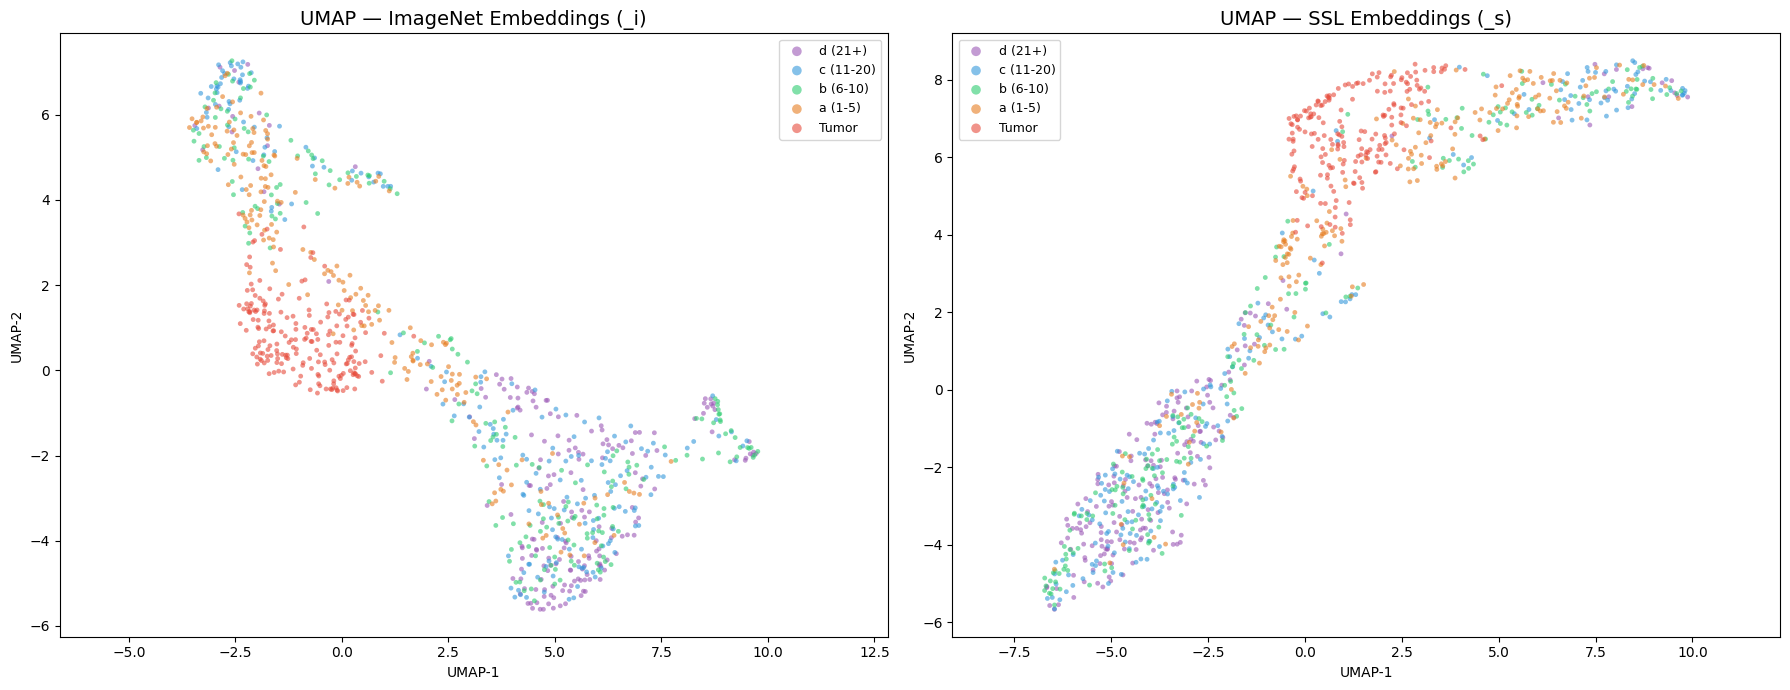

In [7]:
region_order = ['Tumor', 'a (1-5)', 'b (6-10)', 'c (11-20)', 'd (21+)']
color_map = {
    'Tumor':     '#e74c3c',
    'a (1-5)':   '#e67e22',
    'b (6-10)':  '#2ecc71',
    'c (11-20)': '#3498db',
    'd (21+)':   '#9b59b6',
}

def plot_umap(ax, proj, labels, title):
    # Plot distant regions first so tumor is drawn on top
    for region in reversed(region_order):
        mask = labels == region
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   c=color_map[region], label=region,
                   s=12, alpha=0.6, edgecolors='none')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    ax.legend(fontsize=9, markerscale=2)
    ax.set_aspect('equal', adjustable='datalim')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_umap(axes[0], proj_i, region_labels, 'UMAP — ImageNet Embeddings (_i)')
plot_umap(axes[1], proj_s, region_labels, 'UMAP — SSL Embeddings (_s)')
plt.tight_layout()
plt.show()

## 7. Spatial Map: Sampled Tiles on Grid

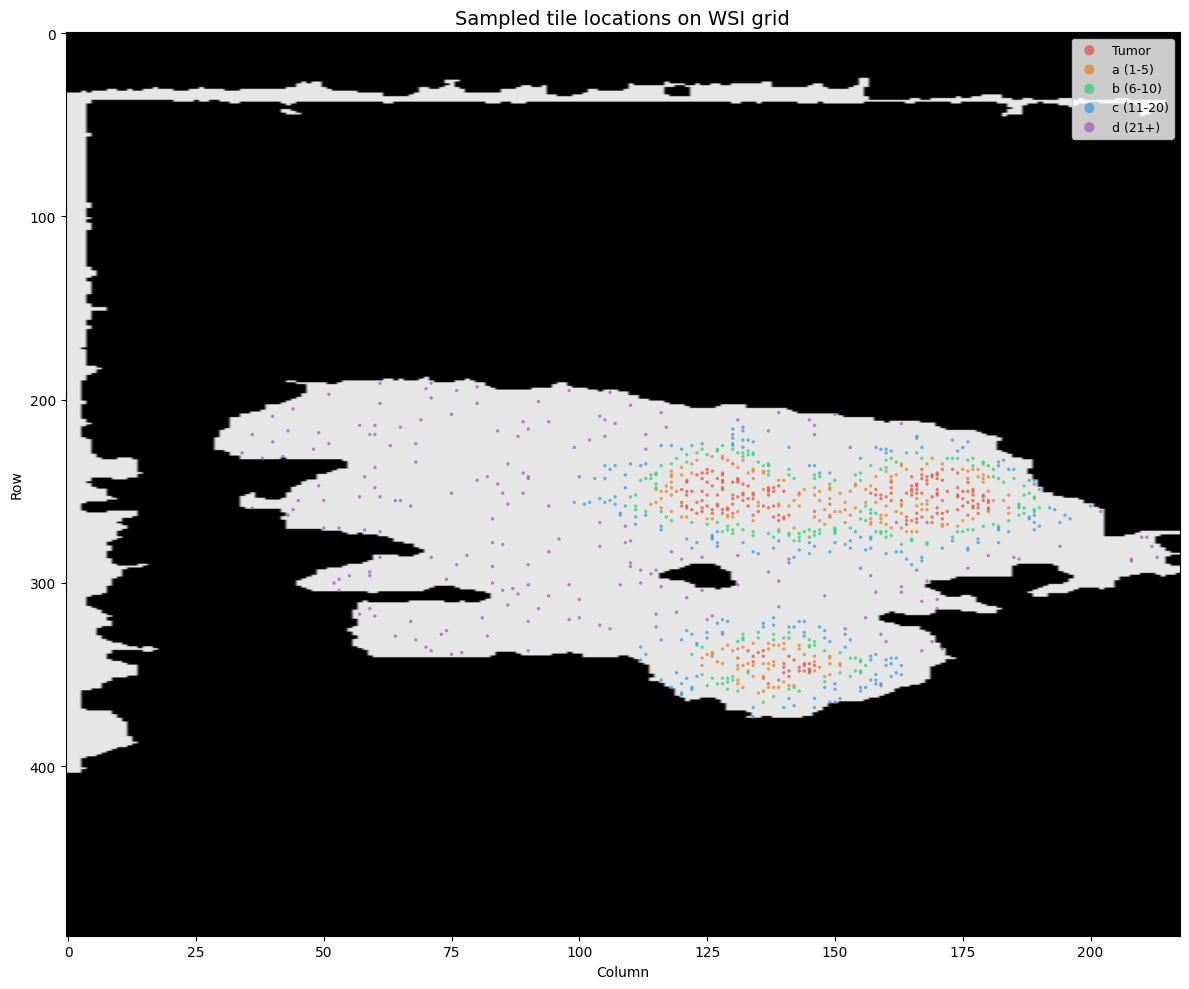

In [8]:
# Show where the sampled tiles fall on the WSI grid
fig, ax = plt.subplots(figsize=(12, 10))

# Background: tissue in light gray
canvas = np.zeros((env.n_rows, env.n_cols, 3), dtype=np.uint8)
canvas[env.tissue_grid] = [230, 230, 230]
ax.imshow(canvas, aspect='auto')

# Overlay sampled tiles
for region in region_order:
    mask = region_labels == region
    rc = sampled_rc[mask]
    ax.scatter(rc[:, 1], rc[:, 0],  # col=x, row=y
               c=color_map[region], label=region,
               s=6, alpha=0.7, edgecolors='none')

ax.set_title('Sampled tile locations on WSI grid', fontsize=14)
ax.set_xlabel('Column')
ax.set_ylabel('Row')
ax.legend(fontsize=9, markerscale=3, loc='upper right')
plt.tight_layout()
plt.show()

## 8. Quantitative Analysis: Inter-region Distances

In [9]:
from scipy.spatial.distance import cdist

def region_centroid_distances(emb, labels, region_order, metric='cosine'):
    """Compute pairwise mean cosine distance between region centroids."""
    centroids = []
    for r in region_order:
        centroids.append(emb[labels == r].mean(axis=0))
    centroids = np.vstack(centroids)
    return cdist(centroids, centroids, metric=metric)

print("=== ImageNet Embedding Inter-region Cosine Distance ===")
dist_i = region_centroid_distances(emb_i, region_labels, region_order)
for i, r in enumerate(region_order):
    vals = "  ".join(f"{d:.4f}" for d in dist_i[i])
    print(f"  {r:12s}: {vals}")

print("\n=== SSL Embedding Inter-region Cosine Distance ===")
dist_s = region_centroid_distances(emb_s, region_labels, region_order)
for i, r in enumerate(region_order):
    vals = "  ".join(f"{d:.4f}" for d in dist_s[i])
    print(f"  {r:12s}: {vals}")

=== ImageNet Embedding Inter-region Cosine Distance ===
  Tumor       : 0.0000  0.0545  0.1326  0.1581  0.2469
  a (1-5)     : 0.0545  0.0000  0.0438  0.0629  0.1540
  b (6-10)    : 0.1326  0.0438  0.0000  0.0047  0.0451
  c (11-20)   : 0.1581  0.0629  0.0047  0.0000  0.0301
  d (21+)     : 0.2469  0.1540  0.0451  0.0301  0.0000

=== SSL Embedding Inter-region Cosine Distance ===
  Tumor       : 0.0000  0.0009  0.0036  0.0045  0.0077
  a (1-5)     : 0.0009  0.0000  0.0013  0.0019  0.0046
  b (6-10)    : 0.0036  0.0013  0.0000  0.0001  0.0010
  c (11-20)   : 0.0045  0.0019  0.0001  0.0000  0.0007
  d (21+)     : 0.0077  0.0046  0.0010  0.0007  0.0000


## 9. Cleanup

In [10]:
del env
print("Done.")

Done.
